# **Models of Stock Return**
In this Notebook, I apply the concept of probability to measure the probability that the stock price drops a certain percentage in a day, and in a year.

I also demonstrate how to calculate the value at risk (VaR) using python.

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
%matplotlib inline

In [75]:
#upload required stock data
files.upload()

{}

In [76]:
fb = pd.read_csv('/content/drive/MyDrive/Python Projects/Datasets/facebook.csv')
fb.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-12-31,20.400000,20.510000,19.990000,20.049999,19.459270,4157500
1,2015-01-02,20.129999,20.280001,19.809999,20.129999,19.536913,2842000
2,2015-01-05,20.129999,20.190001,19.700001,19.790001,19.206934,4948800
3,2015-01-06,19.820000,19.840000,19.170000,19.190001,18.624611,4944100
4,2015-01-07,19.330000,19.500000,19.080000,19.139999,18.576082,8045200


##**Distribution of Log return**

In [77]:
# let's play around with fb data by calculating the log daily return
fb['LogReturn'] = np.log(fb['Close']).shift(-1) - np.log(fb['Close'])

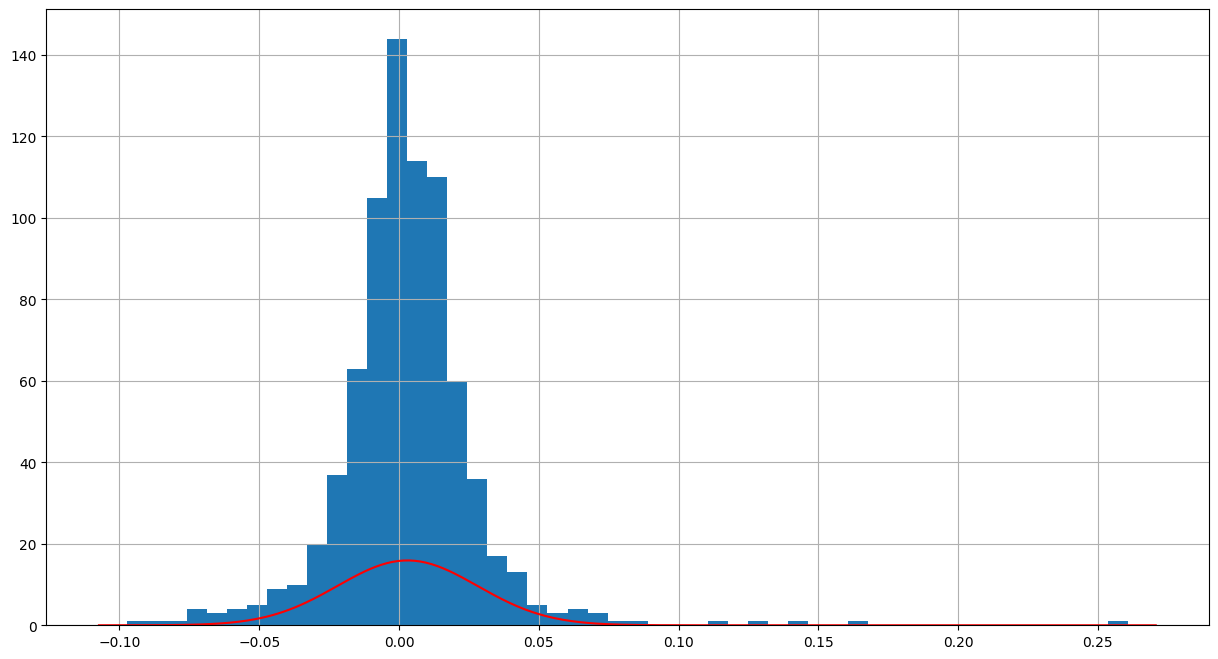

In [78]:
# plot a histogram to show the distribution of log return of Facebook's stock.
# you can see it is very close to a normal distribution
from scipy.stats import norm
mu = fb['LogReturn'].mean()
sigma = fb['LogReturn'].std(ddof=1)

density = pd.DataFrame()
density['x'] = np.arange(fb['LogReturn'].min()-0.01, fb['LogReturn'].max()+0.01, 0.001)
density['pdf'] = norm.pdf(density['x'], mu, sigma)

fb['LogReturn'].hist(bins=50, figsize=(15, 8))
plt.plot(density['x'], density['pdf'], color='red')
plt.show()

## **Calculating the probability of the stock price dropping over a certain percentage in a day**

Use the python function: q = norm.cdf(z, mean, std dev).

**🎯 What the Function Tells You:**

"What’s the probability that a value from a normal distribution (with the given mean and standard deviation) is less than or equal to a certain point z?"

The result q is a number between 0 and 1 (a probability).

For example, if q = 0.11, it means:

“There’s an 11% chance the return will be -z% or worse.”

In [79]:
# probability that the stock price of facebook will drop over 5% in a day
prob_return1 = norm.cdf(-0.05, mu, sigma)
print('The Probability is ', prob_return1)

The Probability is  0.01716076590410781


In [80]:
# the probability that the stock price of microsoft will drop over 10% in a day
prob_return2 = norm.cdf(-0.10, mu, sigma)
print('The Probability is ', prob_return2)

The Probability is  1.966843199127051e-05


## **Calculating the probability of the stock price dropping over a certain percentage in a year**

In [81]:
# drop over 40% in 220 days
mu220 = 220*mu
sigma220 = (220**0.5) * sigma
print('The probability of dropping over 40% in 220 days is ', norm.cdf(-0.4, mu220, sigma220))

The probability of dropping over 40% in 220 days is  0.002027508122349807


In [82]:
# drop over 20% in 220 days
mu220 = 220*mu
sigma220 = (220**0.5) * sigma
drop20 = norm.cdf(-0.2, mu220, sigma220)
print('The probability of dropping over 20% in 220 days is ', drop20)

The probability of dropping over 20% in 220 days is  0.00975030138031559


## **Calculating Value at Risk (VaR)**
Value at Risk (VaR) is a risk management metric used in finance to quantify the potential loss in value of a portfolio or investment under normal market conditions over a set time period and with a given level of confidence.

It answers the question:

>"What’s the maximum expected loss over a specific time horizon, with a certain level of confidence?"

**Limitations:**

1.   **Does not predict worst-case loss**, only a threshold.
2.   Assumes normal market conditions – **underestimates tail risk.**


A commonly used method to calculate VaR is the **Variance-Covariance (Parametric)**, which assumes returns are normally distributed (which is the case in my example above) and uses standard deviation.

Now let's estimate how much you could lose in a given time frame, **assuming returns are normally distributed.**

In [83]:
# Value at risk(VaR)
# 5% quantile
VaR = norm.ppf(0.05, mu, sigma) # use <distribution>.ppf() for non.normal data :)
print('Single day value at risk ', VaR) # can be interpreted as there's a 5% chance that the return would be worse than 0.022523362407065 and a 95% chance it won't be more than 0.022523362407065.

# 25% quantile
q25 = (norm.ppf(0.25, mu, sigma))
print('25% quantile ', q25)


Single day value at risk  -0.038185354350792663
25% quantile  -0.013866270900421623


VaR results on 5% quantile can be interpreted that there's a 5% chance that the return will be below 0.022523362407065 and a 95% chance it won't be worse than that. 😊